# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## Ranked Actions + Reason Codes

The ranked action queue is intended to help prioritize content for manual review. Pages are ranked using the baseline score developed in earlier assignments. The recommendations provide decision-support only and should not be applied automatically without human review.

In [16]:
df["stale"] = (df["days_since_last_update"] >= 180).astype(int)
df["visible"] = (df["impressions_90d"] >= 500).astype(int)
df["low_ctr"] = (df["ctr"] < 1).astype(int)

df["baseline_score"] = (
    40 * df["stale"] +
    30 * df["visible"] +
    30 * df["low_ctr"]
)

df["high_priority"] = (df["baseline_score"] >= 70).astype(int)

In [17]:
df["action"] = "Monitor"

df.loc[df["baseline_score"] >= 70, "action"] = "Refresh Content"

df.loc[
    (df["baseline_score"] >= 40) &
    (df["baseline_score"] < 70),
    "action"
] = "Review Content"

In [18]:
df["reason_code"] = "Healthy Performance"

df.loc[df["stale"] == 1, "reason_code"] = "Stale Content"

df.loc[df["low_ctr"] == 1, "reason_code"] = "Low CTR"

df.loc[
    (df["stale"] == 1) &
    (df["visible"] == 1) &
    (df["low_ctr"] == 1),
    "reason_code"
] = "Stale + High Impressions + Low CTR"

In [19]:
queue = df[
    [
        "content_id",
        "baseline_score",
        "action",
        "reason_code"
    ]
].sort_values(
    by="baseline_score",
    ascending=False
)

queue.head(10)

,content_id,baseline_score,action,reason_code
26840,content_7f116ae1f6f5,100,Refresh Content,Stale + High Impressions + Low CTR
5327,content_fe16a55cd13d,100,Refresh Content,Stale + High Impressions + Low CTR
7021,content_1bfaa38ff26c,100,Refresh Content,Stale + High Impressions + Low CTR
26799,content_77d4d5930e5e,100,Refresh Content,Stale + High Impressions + Low CTR
21268,content_0a91db491d14,100,Refresh Content,Stale + High Impressions + Low CTR
20837,content_928af3e22c80,100,Refresh Content,Stale + High Impressions + Low CTR
22872,content_e3ff1b093148,100,Refresh Content,Stale + High Impressions + Low CTR
23215,content_bdbec75c1148,100,Refresh Content,Stale + High Impressions + Low CTR
12045,content_c2d929d83eaa,100,Refresh Content,Stale + High Impressions + Low CTR
11630,content_6226ee6adc91,100,Refresh Content,Stale + High Impressions + Low CTR


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## Intended Use

This playbook is intended to help content teams prioritize pages for manual review. The ranked queue provides decision-support by identifying pages that may benefit from refreshing or optimization.

## Limits

The recommendations are based on historical data and rule-based scoring. They do not guarantee future performance and should not replace editorial judgment. The playbook was evaluated on the available dataset and may require updates as new data becomes available.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Human Review

Before taking action, reviewers should verify:

- Search intent still matches the topic.
- Content is factually accurate.
- Recent business priorities are considered.
- Important pages are not removed accidentally.

## No-Go List

The system should not automatically:

- Publish new content.
- Delete pages.
- Rewrite content.
- Change SEO metadata.
- Make business decisions without human approval.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## Monitoring

The playbook should be reviewed periodically.

Retraining should be considered if:

- CTR changes substantially.
- Search rankings shift.
- New content types are introduced.
- Model performance decreases.
- Business priorities change.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [1]:
!git clone https://github.com/JaswanthhKumar22/flyrank-ml-internship.git

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 133, done.
remote: Counting objects: 100% (133/133), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 133 (delta 48), reused 77 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (133/133), 1.86 MiB | 8.29 MiB/s, done.
Resolving deltas: 100% (48/48), done.


In [2]:
%cd flyrank-ml-internship

/content/flyrank-ml-internship


In [4]:
import pandas as pd
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

In [6]:
df["stale"] = (df["days_since_last_update"] >= 180).astype(int)
df["visible"] = (df["impressions_90d"] >= 500).astype(int)
df["low_ctr"] = (df["ctr"] < 1).astype(int)

df["baseline_score"] = (
    40 * df["stale"] +
    30 * df["visible"] +
    30 * df["low_ctr"]
)

In [7]:
df["action"] = "Monitor"

df.loc[df["baseline_score"] >= 70, "action"] = "Refresh Content"

df.loc[
    (df["baseline_score"] >= 40) &
    (df["baseline_score"] < 70),
    "action"
] = "Review Content"

In [8]:
df["reason_code"] = "Healthy"

df.loc[df["stale"] == 1, "reason_code"] = "Stale Content"

df.loc[df["low_ctr"] == 1, "reason_code"] = "Low CTR"

df.loc[
    (df["stale"] == 1) &
    (df["visible"] == 1) &
    (df["low_ctr"] == 1),
    "reason_code"
] = "Stale + High Impressions + Low CTR"

In [9]:
queue = df[
    [
        "content_id",
        "baseline_score",
        "action",
        "reason_code"
    ]
].sort_values(
    by="baseline_score",
    ascending=False
)

queue.head()

,content_id,baseline_score,action,reason_code
26840,content_7f116ae1f6f5,100,Refresh Content,Stale + High Impressions + Low CTR
5327,content_fe16a55cd13d,100,Refresh Content,Stale + High Impressions + Low CTR
7021,content_1bfaa38ff26c,100,Refresh Content,Stale + High Impressions + Low CTR
26799,content_77d4d5930e5e,100,Refresh Content,Stale + High Impressions + Low CTR
21268,content_0a91db491d14,100,Refresh Content,Stale + High Impressions + Low CTR


In [11]:
from pathlib import Path

Path("work/outputs").mkdir(parents=True, exist_ok=True)

In [12]:
queue.to_csv(
    "work/outputs/content_action_queue.csv",
    index=False
)

In [13]:
from pathlib import Path

Path("work/outputs").mkdir(parents=True, exist_ok=True)
Path("work/figures").mkdir(parents=True, exist_ok=True)

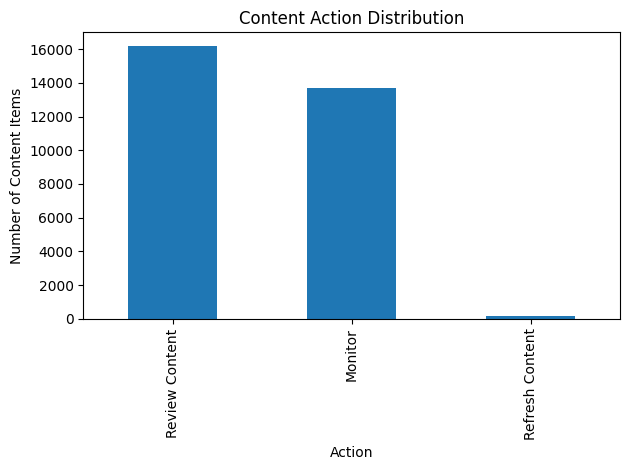

In [15]:
import matplotlib.pyplot as plt

action_counts = queue["action"].value_counts()

action_counts.plot(kind="bar")

plt.title("Content Action Distribution")
plt.xlabel("Action")
plt.ylabel("Number of Content Items")

plt.tight_layout()
plt.savefig("work/figures/action_distribution.png")

plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [*] Every section above is filled — markdown thinking AND the code that backs it
- [*] The notebook runs top to bottom with no errors (Runtime → Run all)
- [*] No client names, URLs, or private queries anywhere
- [*] My claims use careful words: observed, measured, directional, decision-support
- [*] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.